In [502]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl


from copy import copy 
import numpy as np
import matplotlib.pyplot as plt

<AxesSubplot:>

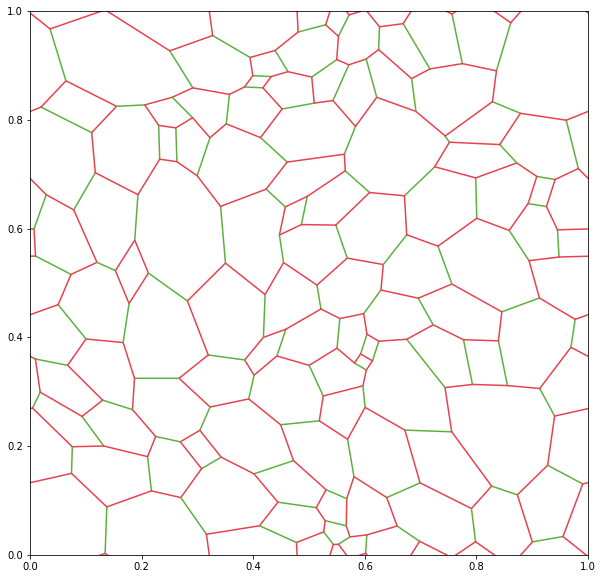

In [503]:
points = uniform(100)
lattice = generate_lattice(points)

dimer = gu.dimerise(lattice)
coloring = color_lattice(lattice)

dimer_list = np.where(dimer == 1)[0]
fig, ax = plt.subplots(figsize = (10,10))
pl.plot_edges(lattice,dimer)

<AxesSubplot:>

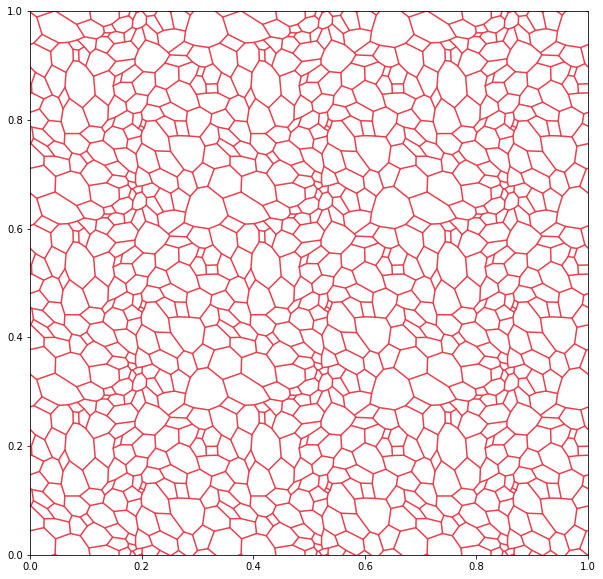

In [504]:

from koala.graph_utils import _remove_vertices_backend


def tile_unit_cell(unit_points, unit_edges,unit_crossing, n_xy):
    
    total_cells = np.prod(n_xy)
    x_shift = np.arange(n_xy[0])
    y_shift = np.arange(n_xy[1])
    x_shift, y_shift = np.meshgrid(x_shift, y_shift)

    shifts = np.array([x_shift.flatten(),y_shift.flatten()]).T.astype(int)
    def _sector_to_number(sector, n_xy): return sector[0]%n_xy[0] + (sector[1]%n_xy[1])*n_xy[0]
    
    # make nx x ny copies of the unit cell
    new_points = (unit_points[:,None] + shifts[None,:,:]).reshape(-1,2)/n_xy
    new_edges = np.kron(unit_edges*total_cells, np.ones((total_cells,1))).astype(int)
    new_crossing = np.kron(unit_crossing, np.ones((total_cells,1))).astype(int)
    
    # for each edge, calculate the sector change and rewire the edge plus the crossing
    for n, (edge, crossing) in enumerate(zip(new_edges, new_crossing)):
        
        sector_number = n % total_cells
        sector = shifts[sector_number]
        next_sector = sector + crossing

        next_sector_number = _sector_to_number(next_sector, n_xy)
        sector_change = [sector_number,next_sector_number]

        new_edges[n] = edge + sector_change % total_cells
        new_crossing[n] =  next_sector // n_xy        

    return Lattice(new_points, new_edges, new_crossing)


n_xy = [3,3]

ltiled = tile_unit_cell(
            lattice.vertices.positions, 
            lattice.edges.indices, 
            lattice.edges.crossing,
            n_xy
        )

fig, ax = plt.subplots(figsize = (10,10))
pl.plot_edges(ltiled, ax=ax)

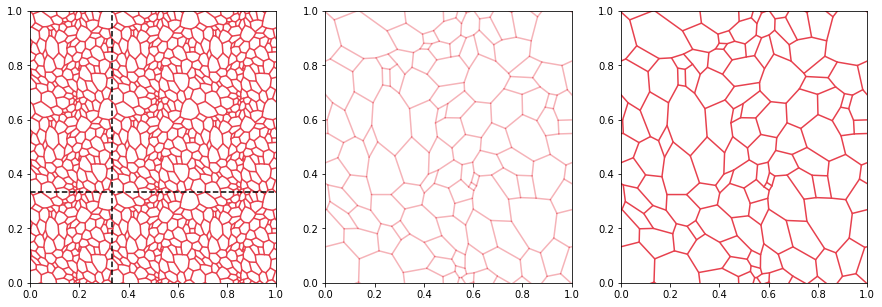

In [505]:

def _untile_unit_cell(unit_points, unit_edges,unit_crossing, n_xy):

    # make sure nxy>2
    if np.any(np.array(n_xy) <= 2):
        raise ValueError("you must tile at least 3x in each direction, otherwise the untiling is ambiguous")

    vertex_sectors = unit_points*n_xy // (1)
    vertices_to_remove = np.argwhere(np.any(vertex_sectors != 0, axis = 1)).flatten()

    # remove all edges that dont even touch the original unit cell
    edge_sectors = vertex_sectors[unit_edges]
    keep_edges = np.all(edge_sectors[:,0,:] == 0, axis = (1))
    edges_trimmed = unit_edges[keep_edges]
    crossing_trimmed = unit_crossing[keep_edges]
    edge_sectors = edge_sectors[keep_edges]

    sector_diff = - edge_sectors[:,1,:]
    sector_diff = ((sector_diff+1) % n_xy )-1
    
    crossing_trimmed = - sector_diff
    

    # make a list of what every vertex is remapped to
    vertex_remapped_positions = (unit_points*n_xy%1) / n_xy
    vertex_remap_indices = np.zeros(unit_points.shape[0], dtype = int)
    for i in range(unit_points.shape[0]):
        r = unit_points - vertex_remapped_positions[i]
        vertex_remap_indices[i] = np.argmin(np.sum(r**2, axis = 1))

    # remap the edges
    edges_trimmed = vertex_remap_indices[edges_trimmed]

    # expand vertices
    enlarged_points = unit_points*n_xy

    # remove duplicate vertices
    enlarged_points, edges_trimmed, crossing_trimmed = _remove_vertices_backend(enlarged_points, edges_trimmed, crossing_trimmed,vertices_to_remove)

    return enlarged_points, edges_trimmed, crossing_trimmed




l_untiled = Lattice(*_untile_unit_cell(
    ltiled.vertices.positions,
    ltiled.edges.indices,
    ltiled.edges.crossing,
    n_xy
))


fig, ax = plt.subplots(1,3, figsize = (15,5))
pl.plot_edges(ltiled, ax = ax[0])
pl.plot_edges(l_untiled, ax = ax[1], alpha = 0.4)
pl.plot_edges(lattice, ax = ax[2])

for a in ax[:1]:
    a.axvline(1/n_xy[0], color = 'k', linestyle = '--')
    a.axhline(1/n_xy[1], color = 'k', linestyle = '--')

<AxesSubplot:>

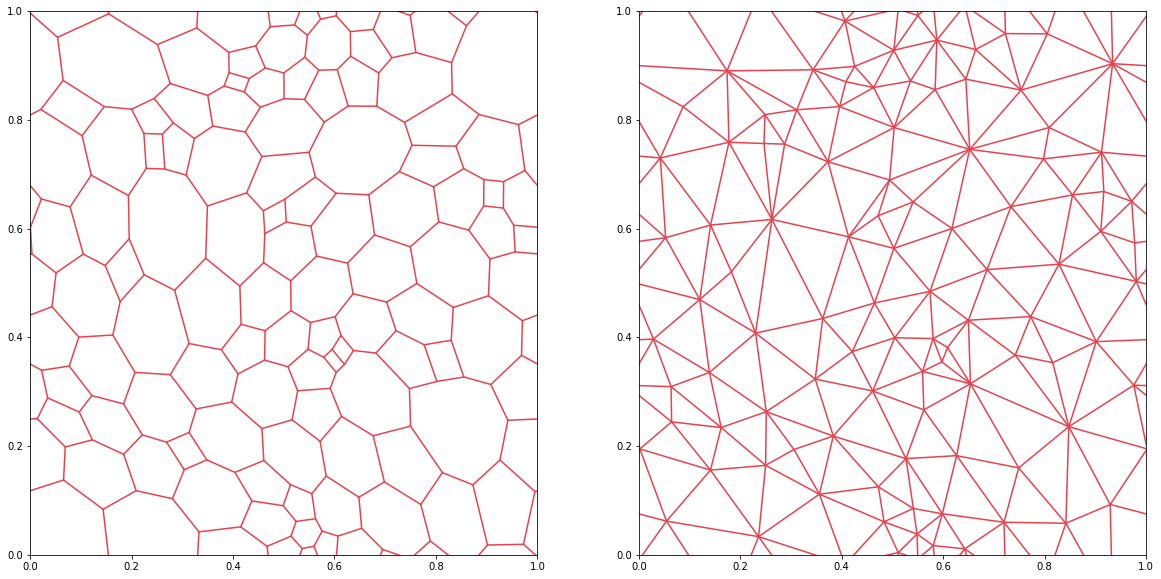

In [506]:


from koala.lattice import INVALID
def make_dual(lattice: Lattice, use_point_averages = False) -> Lattice:
    """Given a lattice, generate the dual lattice

    Args:
        lattice (Lattice): Input lattice

    Returns:
        Lattice: The dual lattice
    """

    graph_small = lattice.n_plaquettes<30

    if graph_small:
        n_xy = [3,3]
        lattice = tile_unit_cell(
            lattice.vertices.positions, 
            lattice.edges.indices, 
            lattice.edges.crossing,
            n_xy
        )

    # set vertices of dual lattice at centers of initial lattice
    if use_point_averages:
        dual_verts = np.zeros((lattice.n_plaquettes, 2))
        for i, p in enumerate(lattice.plaquettes):
            plaquette_vectors = lattice.edges.vectors[
                p.edges] * p.directions[:, None]
            plaquette_sums = np.cumsum(plaquette_vectors, 0)
            points = lattice.vertices.positions[p.vertices[0]] + plaquette_sums
            dual_verts[i] = np.mean(points, axis=0)%1
    else:
        dual_verts = np.array([p.center for p in lattice.plaquettes])%1

    # make edges, taking care to remove any edges that connect to the outer boundary of the lattice
    dual_edges = lattice.edges.adjacent_plaquettes
    rows_to_keep = np.where(np.any(dual_edges != INVALID, axis=1))[0]
    cleaned_edges = dual_edges[rows_to_keep]

    # crossing is sorted out by checking whether the edges cross over half the system
    dual_crossing = np.round(dual_verts[cleaned_edges[:, 0]] -
                             dual_verts[cleaned_edges[:, 1]])

    # TODO - currently we just check if it broke and raise an error -- this isnt
    # perfect and something will have to be fixed in the future
    combined_edge_crossing = np.concatenate([cleaned_edges, dual_crossing], axis=1)
    unique_rows, counts = np.unique(combined_edge_crossing, axis=0, return_counts=True)

    if np.any(counts > 1):
        print(counts)
        print(unique_rows[counts > 1])
        raise Exception(
            "Dual is not currently designed to deal with lattices so small,\
                put more points in the lattice or cut boundaries")

    if graph_small:
        dual_verts, cleaned_edges, dual_crossing = _untile_unit_cell(
            dual_verts, 
            cleaned_edges, 
            dual_crossing,
            n_xy
        )

    # make the lattice
    dual = Lattice(dual_verts, cleaned_edges, dual_crossing)
    return dual


dual = make_dual(lattice,True)
lattice = make_dual(dual,True)


fig, ax = plt.subplots(1,2, figsize = (20,10))
pl.plot_edges(lattice, ax = ax[0])
pl.plot_edges(dual, ax = ax[1])




<AxesSubplot:>

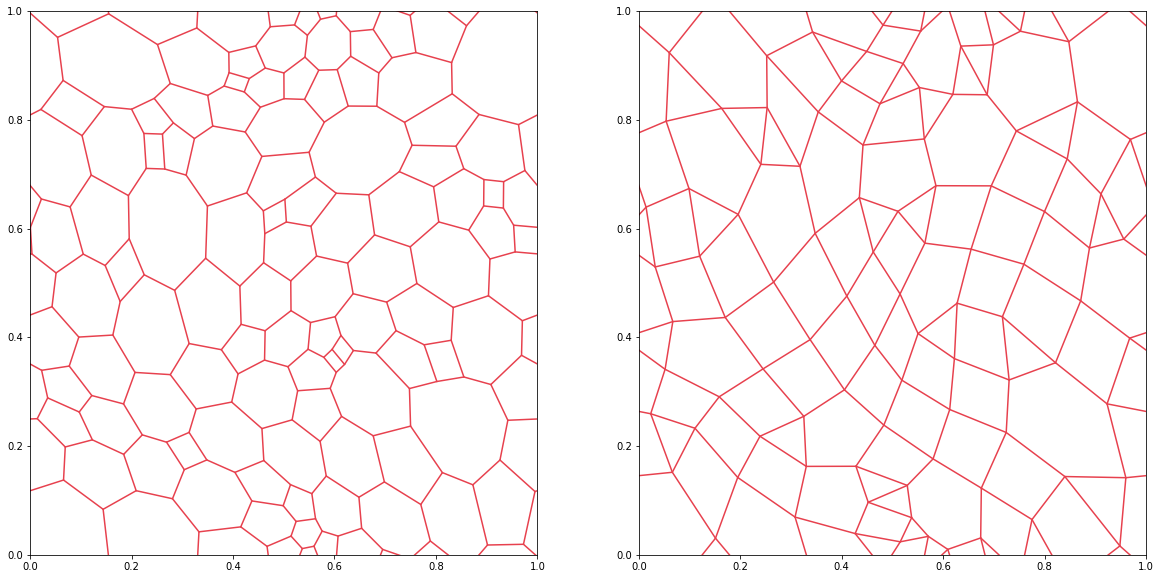

In [507]:

def dimer_collapse(lattice, dimer):
    dual = make_dual(lattice)

    # remove the edges that are in the dimerisation
    fixed_edges = dual.edges.indices[np.where(dimer == 0)[0]]
    dual_crossing = dual.edges.crossing[np.where(dimer == 0)[0]]
    dual_removed = Lattice(dual.vertices.positions, fixed_edges, dual_crossing) 
    
    while 2 in dual_removed.vertices.coordination_numbers:
        dual_removed = gu.remove_vertices(dual_removed, np.where(dual_removed.vertices.coordination_numbers == 2))
    
    four_connected = make_dual(dual_removed)

    return four_connected

collapsed_lattice = dimer_collapse(lattice, dimer)
fig, ax = plt.subplots(1,2, figsize = (20,10))
pl.plot_edges(lattice, ax = ax[0])
pl.plot_edges(collapsed_lattice, ax = ax[1])


In [508]:
def _shift_vertex(lattice_data, chosen_vertex, shift_vector):
    """
    Shifts the position of a chosen vertex in a lattice by a given shift vector, taking into account the periodic boundary conditions.

    Parameters:
    - lattice_data (tuple): A tuple containing the lattice data, including positions, edges, crossing, and adjacent_edges.
    - chosen_vertex (int): The index of the vertex to be shifted.
    - shift_vector (numpy.ndarray): The vector by which the vertex position should be shifted.

    Returns:
    - new_positions (numpy.ndarray): The updated positions of all vertices in the lattice.
    - new_edges (numpy.ndarray): The updated edges of the lattice.
    - new_crossing (numpy.ndarray): The updated crossing information of the lattice.
    """
    # copy inputs to avoid modifying the original data
    positions, edges, crossing, adjacent_edges = lattice_data
    new_positions =  copy(positions)
    new_edges = copy(edges)
    new_crossing = copy(crossing)

    # move the chosen vertex
    vertex_position = new_positions[chosen_vertex]
    new_position = vertex_position + shift_vector
    new_sector = (new_position // 1).astype(int)
    new_positions[chosen_vertex] = new_position%1

    # if the new position is outside the unit cell, update the crossing information
    if np.any(new_sector != 0):
        neighbour_edges = adjacent_edges[chosen_vertex]
        adjacent_indices = new_edges[neighbour_edges]
        signs = 1-2*np.where(adjacent_indices == chosen_vertex)[1]
        new_crossing[neighbour_edges] -= signs[:,None]*(new_sector)

    return new_positions, new_edges, new_crossing
    